In [ ]:
%matplotlib widget
import sys, importlib, os
import McsPy.McsData
import McsPy.McsCMOS
from McsPy import ureg, Q_

# matplotlib.pyplot will be used in these examples to generate the plots visualizing the data
import matplotlib.pyplot as plt
from matplotlib.figure import Figure
from matplotlib.widgets import Slider
import numpy as np
from scipy import signal

# import datashader as ds
# import datashader.transfer_functions as tf
import pandas as pd

na = np.array
import scipy.signal
import matplotlib.pyplot as plt

import numpy as np
import scipy.signal
import matplotlib.pyplot as plt
import h5py
import os 

def detect_events(signal, window_size=5000, threshold_std=5, min_separation=2000,dt=0.0004):
    """
    Detects events in the signal that are above the mean - (threshold_std * std_dev),
    extracts windows around the peaks using the Hilbert transform, ensuring minimum separation between events.

    Parameters:
    signal (np.array): 1D array of signal data.
    window_size (int): Number of samples to include in each window.
    threshold_std (float): Threshold in terms of standard deviations.
    min_separation (int): Minimum number of points between consecutive events.
    
    Returns:
    list of np.array: Extracted event windows.
    """
    # Compute Hilbert transform and envelope
    analytic_signal = scipy.signal.hilbert(signal)
    envelope = np.abs(analytic_signal)
    
    
    mean_val = np.mean(envelope)
    std_val = np.std(envelope)
    threshold = mean_val + (threshold_std * std_val)
    
    # Find indices where signal is below the threshold
    event_indices = np.where(envelope > threshold)[0]
    
    # Ensure events are at least min_separation apart
    filtered_indices = []
    last_idx = -min_separation
    for idx in event_indices:
        if idx - last_idx >= min_separation:
            filtered_indices.append(idx)
            last_idx = idx
    
    
    # Extract windows around the peak of the envelope
    windows = []
    intervals= []
    for idx in filtered_indices:
        peak_idx = idx + np.argmax(envelope[idx:idx + window_size])
        start = max(0, peak_idx)
        end = min(len(signal), peak_idx + window_size // 2)
        windows.append(signal[start:end])
        intervals.append([float(start)*dt,float(end)*dt])
    
    return windows,intervals


In [1]:
# Overview of all possible recordings 
rec_table = pd.read_csv('/mnt/server_epl/SCN1A/R1648H-analysis/recordings-main.csv')

NameError: name 'pd' is not defined

In [3]:
rec_table[rec_table['date'] =='21.3.25']

,date,mouse age,mouseID,slice,Valid,genotype,Sex,recording,protocol,duration,...,recording solution,Perfusion speed,visible areas,dissection,slice type,file_name,path,image_path,harp,comments about slice
143,21.3.25,P18,13,slice1,NaN,?,male,1.0,5-10-10,5.0,...,0Mg,3,hpc,Uli,horizontal,2025-03-21T10-30-21McsRecording,21-3-25\slice1,21-3-25\slice1\stack,OPEN,NaN
144,21.3.25,P18,13,slice1,NaN,?,male,2.0,5-10-10,10.0,...,0Mg,3,hpc,Uli,horizontal,2025-03-20T15-40-59McsRecording,21-3-25\slice1,21-3-25\slice1\stack,OPEN,NaN
145,21.3.25,P18,13,slice1,NaN,?,male,3.0,5-10-10,8.0,...,0Mg,3,hpc,Uli,horizontal,2025-03-21T11-09-44McsRecording,21-3-25\slice1,21-3-25\slice1\stack,OPEN,NaN
146,21.3.25,P18,13,slice2,NaN,?,male,1.0,5-10-10,5.0,...,0Mg,3,hpc,Uli,horizontal,2025-03-21T11-22-54McsRecording,21-3-25\slice2,21-3-25\slice2\stack-e,OPEN,NaN
147,21.3.25,P18,13,slice2,NaN,?,male,2.0,extra,1.0,...,0Mg,3,hpc,Uli,horizontal,2025-03-21T11-33-19McsRecording,21-3-25\slice2,21-3-25\slice2\stack-e,OPEN,NaN
148,21.3.25,P18,13,slice2,NaN,?,male,3.0,5-10-10,10.0,...,0Mg,3,hpc,Uli,horizontal,2025-03-21T11-41-42McsRecording,21-3-25\slice2,21-3-25\slice2\stack-e,OPEN,NaN
149,21.3.25,P18,13,slice2,NaN,?,male,4.0,5-10-10,NaN,...,0Mg,3,hpc,Uli,horizontal,2025-03-21T12-02-22McsRecording,21-3-25\slice2,21-3-25\slice2\stack-e,OPEN,NaN
150,21.3.25,P18,13,slice3,NaN,?,male,1.0,5-10-10,5.0,...,0Mg,3,hpc,Uli,horizontal,2025-03-21T12-20-48McsRecording,21-3-25\slice3,NaN,OPEN,NaN
151,21.3.25,P18,13,slice3,NaN,?,male,NaN,20-30,NaN,...,0Mg,3,hpc,Uli,horizontal,2025-03-21T12-42-43McsRecording,21-3-25\slice3,NaN,OPEN,NaN
152,21.3.25,P18,13,slice4,NaN,?,male,1.0,5-10-10,5.0,...,0Mg,3,hpc,Uli,horizontal,2025-03-21T13-20-16McsRecording,21-3-25\slice4,21-3-25\slice4\stack,OPEN,NaN


In [4]:
#set img path 
i_num = 157
rec_table.iloc[i_num]

img_path = '/mnt/server_epl/SCN1A/R1648/'+rec_table.iloc[i_num].image_path + '/Fused.tif'
img_path =img_path.replace('\\','/')


In [5]:
ch_detection =pd.read_csv('/mnt/server_epl/SCN1A/R1648/21-3-25/slice6/stack/labeled_electrodes.csv')#['e_pos_x']


In [6]:
detection_path = '/mnt/server_epl/SCN1A/R1648/'+rec_table.iloc[i_num].image_path + '/labeled_electrodes.csv'
detection_path =detection_path.replace('\\','/')
ch_detection =pd.read_csv(detection_path)

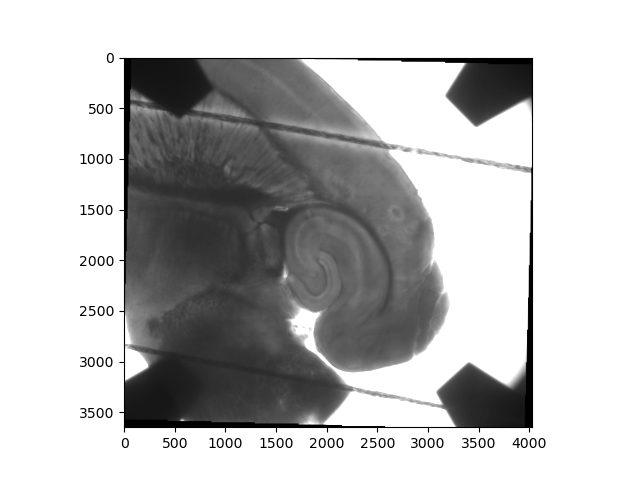

In [7]:
I = plt.imread(img_path)
plt.imshow(I,cmap='gray',vmax=5000)

In [8]:
from datetime import datetime

path = rec_table.iloc[i_num].path.replace('\\','/')
file_name = rec_table.iloc[i_num].file_name
os.path.join(path,file_name)
slice_ =path.split('/')[-1]
date =path.split('/')[0]
dt = datetime.strptime(date, '%d-%m-%y')
date = dt.strftime('%d-%m-%y')
print(date)

filt_file_name = 'R1648H_'+date+'_'+slice_+'_'+file_name+'.h5_filtered.h5'
filt_path = '/mnt/server_epl/SCN1A/R1648H_filt'
target_file = os.path.join(filt_path,filt_file_name).replace('\\','/')


21-03-25


In [12]:
mv_scale_factor =  1000000
with h5py.File(target_file, 'r') as f:
    # print(f.keys())
    print(f['data'].shape)
    filt = f['data'][:,:]
    subsampling_rate = f['resampled_rate']
    subsampling_rate = na(f['resampled_rate'])
    adc_step = na(f['scale'])

(4492000, 252)


([<matplotlib.lines.Line2D at 0x74eed97389a0>],)

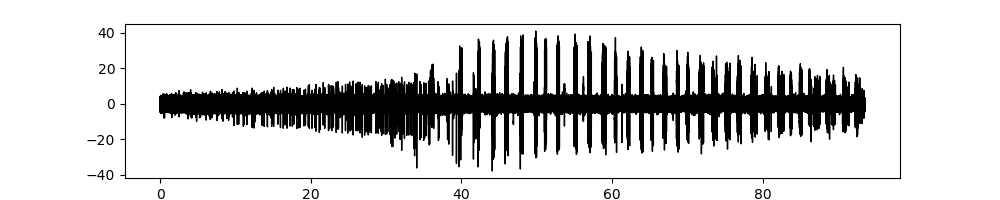

In [13]:
plt.figure(figsize = (10,2))
import matplotlib.patches as patches

#68,70,72,74,76,78

#141
plt.plot(np.arange(0,len(filt[:]))*(1/subsampling_rate)/60,(filt[:,68]*adc_step)*mv_scale_factor,'-',linewidth = 1,color='k'),#);
# plt.plot(np.arange(0,len(filt[:]))*(1/subsampling_rate)/60,(filt[:,18]*adc_step)*mv_scale_factor,'-',linewidth = 1,color='r'),#);
# plt.plot(np.arange(0,len(filt[:]))*(1/subsampling_rate)/60,(filt[:,7]*adc_step)*mv_scale_factor,'-',linewidth = 1,color='r'),#);
# plt.xlim(85,140.3)
# plt.plot([2,3],[-.00005,-.00005],color='k')

In [48]:
import numpy as np
import scipy.signal
from scipy.ndimage import gaussian_filter1d

def detect_events(signal, window_size=5000, threshold_std=5, min_separation=2000,
                  dt=0.0004, smoothing_sigma=10):
    """
    Detects events in the signal using Hilbert envelope + Gaussian smoothing,
    extracts windows around peaks ensuring minimum separation.

    Parameters:
    signal (np.array): 1D array of signal data.
    window_size (int): Number of samples in each extracted window.
    threshold_std (float): Detection threshold in standard deviations.
    min_separation (int): Minimum separation between detected events (samples).
    dt (float): Sampling interval (s).
    smoothing_sigma (float): Sigma for Gaussian smoothing (samples).

    Returns:
    envelope (np.array): Smoothed Hilbert envelope.
    windows (list of np.array): Extracted event windows.
    intervals (list of [start, end]): Time intervals (s) of each window.
    """
    # Hilbert envelope
    analytic_signal = scipy.signal.hilbert(signal)
    envelope = np.abs(analytic_signal)
    
    # Gaussian smoothing
    envelope = gaussian_filter1d(envelope, sigma=smoothing_sigma)

    # Thresholding
    mean_val = np.mean(envelope)
    std_val = np.std(envelope)
    threshold = mean_val + (threshold_std * std_val)
    
    event_indices = np.where(envelope > threshold)[0]
    
    # Filter close events
    filtered_indices = []
    last_idx = -min_separation
    for idx in event_indices:
        if idx - last_idx >= min_separation:
            filtered_indices.append(idx)
            last_idx = idx

    # Extract windows
    windows = []
    intervals = []
    for idx in filtered_indices:
        peak_idx = idx + np.argmax(envelope[idx:idx + window_size])
        start = max(0, peak_idx)
        end = min(len(signal), peak_idx + window_size // 2)
        windows.append(signal[start:end])
        intervals.append([start * dt, end * dt])
    
    return envelope, windows, intervals

In [58]:
envelope,windows,intervals = detect_events(filt[:,68], window_size=10000, threshold_std=5, min_separation=5000,dt=1/subsampling_rate,smoothing_sigma=100)

In [ ]:
# plt.plot(np.arange(0,len(filt[:]))*(1/subsampling_rate)/60,(filt[:,68]*adc_step)*mv_scale_factor,'-',linewidth = 1,color='k'),#);
plt.figure()
# plt.plot(np.arange(0,len(filt[:]))*(1/subsampling_rate),(filt[:,68]*adc_step)*mv_scale_factor,'-',linewidth = 1,color='k'),#);
plt.plot(np.arange(0,len(filt[:]))*(1/subsampling_rate),envelope/10,'-',linewidth = 1,color='r',alpha=0.5),#);
[plt.axvspan(b[0],b[1],alpha=0.5) for b in intervals];